# Colab Base para el Trabajo Práctico (Entrega 2)

Programa de creación de la entrega 2

In [4]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn import model_selection
from sklearn import ensemble
from sklearn import metrics

In [5]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Lectura de datos

In [6]:
# TODO: Cambiar para que apunte al directorio correcto
DIR = "/content/drive/MyDrive" + "/UBA/Especializacion/DM/Data"

## 1.Entender los datos (AID)
```python
df_ent.columns
df_ent.shape()
df_ent.describe()
df_ent.info()

print(f"Dataset a predecir - Operaciones:\n-{df_ap.operation_type.unique()}\n")
print(f"Dataset a entrenar - Operaciones:\n-{df_ent.operation_type.unique()}")
print("-"*90)

print(f"Dataset a predecir - Propiedad:\n-{df_ap.property_type.unique()}\n")
print(f"Dataset a entrenar - Propiedad:\n-{df_ent.property_type.unique()}")
print("-"*90)

print(f"Dataset a predecir - País:\n-{df_ap.location_0.unique()}\n")
print(f"Dataset a entrenar - País:\n-{df_ent.location_0.unique()}\n")
print("-"*90)
print(f"Dataset a predecir - Provincia:\n-{df_ap.location_1.unique()}\n")
print(f"Dataset a entrenar - Provincia:\n-{df_ent.location_1.unique()}\n")
print("-"*90)
print(f"Dataset a predecir - Ciudad:\n-{df_ap.location_2.unique()}\n")
print(f"Dataset a entrenar - Ciudad:\n-{df_ent.location_2.unique()}")
print("-"*90)

print(f"Dataset a predecir - Moneda:\n-{df_ap.currency_type.unique()}\n")
print(f"Dataset a entrenar - Moneda:\n-{df_ent.currency_type.unique()}\n")
print("-"*90)
print(f"Dataset a predecir - Fuente de datos:\n-{df_ap.source.unique()}\n")
print(f"Dataset a entrenar - Fuente de datos:\n-{df_ent.source.unique()}\n")
print("-"*90)
```

## 2.Limpiar y transformar los datos (DM)

## 2.1. Filtrado de datos
``` python
# Selección de datos. Solo a fines demostrativos.
# TODO: CAMBIAR!
# Entrenamiento se basa en los parámentreos lon y lat, este filtro lo haremos por geolocalización,
#  operación, tipo de propiedad, moneda, fuente de datos
filtro = ((df_ent["location_0"] == 'Argentina') &
 (df_ent["location_1"].isin(['Ciudad Autónoma de Buenos Aires','Capital Federal', 'CABA'])) &
          (df_ent["operation_type"] == "venta") &
          (df_ent["property_type"].isin(['casa','departamento', "departamentos", "casas"])) &
          (df_ent["currency_type"].isin(['dolares']))   &
          (df_ent["price" ] < 700000) &
          (~df_ent["price"].isna()) &
           (df_ent["price"]!=0))
df_ent = df_ent.loc[filtro]
df_ent.shape
```


Una vez definido el filtrado de información, se guarda el dataset en un csv. De forma tal, que en los próximos análisis, evite la conexión a la base de datos y el proceso de filtrado.
```python
# Guardo el dataframe en un csv, para luego acceder más facil.
df_ent.to_csv("/content/drive/MyDrive/UBA/Especializacion/DM/Data/raw/entrenamiento.csv")
```

## 2.2 Creación de nuevos atributos

In [7]:
# Lectura del archivo filtrado.
df_ent = pd.read_csv("/content/drive/MyDrive/UBA/Especializacion/DM/Data/raw/entrenamiento.csv", index_col="id")
df_ent.shape

/tmp/ipykernel_4347/3266242235.py:2: DtypeWarning: Columns (5,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ent = pd.read_csv("/content/drive/MyDrive/UBA/Especializacion/DM/Data/raw/entrenamiento.csv", index_col="id")


(106186, 17)

Para poder ver la tablas en un ancho definido y no  acotada. Esto mejora la visualización

In [9]:
# Muestra sin restricción
pd.set_option('display.max_colwidth', None)
# retoran a la configuración de fábrica
# pd.reset_option('display.max_colwidth')

In [10]:
df_ent.features

,features
id,
3659,1 baño;37 m²;internet;cocina equipada;electricidad;aire acondicionado;gas natural;seguridad;pileta;gimnasio;cerca de:
94162,280 m²;cocina equipada;electricidad;cerca de:
94213,4 dormitorios;2 baños;630 m²;garage;cerca de:
94216,5 baños;1.200 m²;internet;electricidad;gas natural;cerca de:
94351,3 dormitorios;3 baños;400 m²;gas natural;electricidad;agua;cerca de:
...,...
1270147,sup. cubierta:36 m² cubierta; antiguedad:a estrenar; baños:1 baño; ambientes:monoambiente; estado:bueno; departamento; cant. ambientes:1; cant. baños:1; estado:bueno; expensas:$ 180.000; apto crédito; tipo de operación:venta; precio:usd 85.000
1270148,"sup. cubierta:38,92 m² cubierta; antiguedad:3 años; baños:1 baño; ambientes:monoambiente; estado:excelente; departamento; cant. ambientes:1; cant. baños:1; estado:excelente; antiguedad:3; expensas:$ 65.000; tipo de operación:venta; precio:usd 69.500; balcón"
1270304,sup. cubierta:56 m² cubierta; dormitorios:2 dormitorios; baños:1 baño; ambientes:3 ambientes; departamento; cant. ambientes:3; cant. dormitorios:2; cant. baños:1; apto crédito; tipo de unidad:departamento; tipo de operación:venta; precio:usd 41.000


**Anáisis del atributo features**

con el comando extract utilizando expresiones regulares.\
Atributos posibles:


*   baños
*   dormitorios
*   superficie
*   superficie cubierta




In [11]:
# dormitorios
dormitorios = df_ent.loc[:,"features"].str.extract(r"(\d+) dormitorios;|dormitorio: (\d+);|dormitorios:(\d+);")
df_ent["c_dormitorios"] = dormitorios[0].fillna(dormitorios[1]).fillna(dormitorios[2])

#
# baños
banios = df_ent.loc[:,"features"].str.extract(r"(\d+) baños;|bano: (\d+);|baños:(\d+);")
df_ent["c_baños"] = banios[0].fillna(banios[1]).fillna(banios[2])

# # el garage solo anotaremos tiene SI o NO
garage = df_ent.loc[:,"features"].str.extract(r'(garage);|(cochera):|(cocheras):\d+')
df_ent["garage"]  = garage[0].fillna(garage[1]).fillna(garage[2])
df_ent.loc[df_ent["garage"].isin(["garage","cochera","cocheras"]) , "garage"] = True
df_ent["garage"].fillna(False, inplace=True)

# Superficie
superficie = df_ent.loc[:,"features"].str.extract(r";(\d+)\s*m²|scubierta: (\d+);| superficie total:(\d+)m.{1};|sup.\scubierta:(\d+)\s*m²| tcubierta:\s(\d*,\d*)\sm²| superficie\stotal:\s(\d+)")
df_ent["superficie"] = superficie[0].fillna(superficie[1]).fillna(superficie[2]).fillna(superficie[3]).fillna(superficie[4]).fillna(superficie[5])


/tmp/ipykernel_4347/3817832990.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ent["garage"].fillna(False, inplace=True)
/tmp/ipykernel_4347/3817832990.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ent["garage"].fillna(False, inplace=True)


In [12]:
df_ent.columns

Index(['description', 'address', 'lat', 'lon', 'publication_date',
       'publisher_id', 'features', 'location_0', 'location_1', 'location_2',
       'location_3', 'location_4', 'operation_type', 'property_type', 'source',
       'price', 'currency_type', 'c_dormitorios', 'c_baños', 'garage',
       'superficie'],
      dtype='object')

## 2.3. Tratamiento de valores atípicos

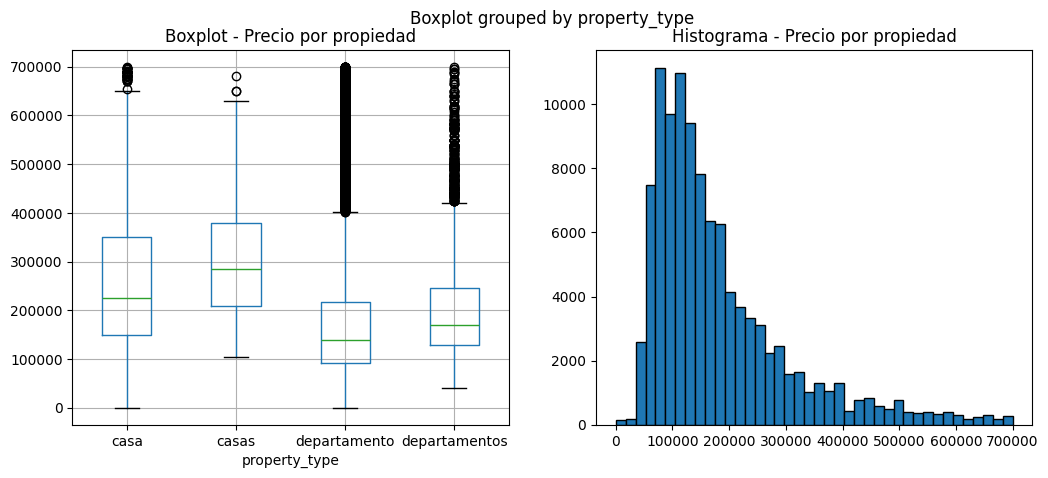

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="price", ax=ax1)
ax1.set_title("Boxplot - Precio por propiedad")

ax2.hist(df_ent["price"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Precio por propiedad")

plt.show()

**Detección por rango intercuartil**\
Muestra una mayor cantidad de valores atípicos en el precio de los departamientos.

In [14]:
def detect_atipico_iqr(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lim_inf = q1 - (iqr * 1.5)
    lim_sup = q3 + (iqr * 1.5)
    return (x < lim_inf) | (x > lim_sup)


In [15]:
precio_departamentos = df_ent.loc[(df_ent["property_type"] == "departamento") |
                                  (df_ent["property_type"] == "departamentos"), "price"]
precio_casas = df_ent.loc[(df_ent["property_type"] == "casa") |
                                  (df_ent["property_type"] == "casas"), "price"]


In [16]:

outliers_iqr_c1 = detect_atipico_iqr(precio_casas)
print(f"Outliers detectados por IQR en el precio de las casas: {outliers_iqr_c1.sum()}")

outliers_iqr_c2 = detect_atipico_iqr(precio_departamentos)
print(f"Outliers detectados por IQR en el precio de los departamentos: {outliers_iqr_c2.sum()}")

Outliers detectados por IQR en el precio de las casas: 62
Outliers detectados por IQR en el precio de los departamentos: 6335


Analizo precio de la propiedad por Barrio

In [17]:
df_ent.location_2.unique()

array(['Buenos Aires', 'Belgrano', 'Palermo', 'Núñez', 'Colegiales',
       'Retiro', 'Montserrat', 'Recoleta', 'Balvanera', 'San Nicolás',
       nan, 'Caballito', 'Almagro', 'Parque Chacabuco', 'Boedo', 'Flores',
       'Villa Crespo', 'Villa Ortúzar', 'Chacarita', 'Paternal',
       'San Cristóbal', 'Villa Urquiza', 'Villa Pueyrredón',
       'Villa Santa Rita', 'Floresta', 'Mataderos', 'Villa Soldati',
       'Parque Avellaneda', 'Villa Lugano', 'Villa Riachuelo',
       'Villa Devoto', 'Agronomía', 'Liniers', 'Nueva Pompeya',
       'San Cristobal', 'Once', 'La Paternal', 'Congreso',
       'Velez Sarsfield', 'Parque Centenario', 'Centro / Microcentro',
       'Barrio Norte', 'Tribunales', 'Villa Luro', 'San Telmo',
       'Puerto Madero', 'Barracas', 'Villa Real', 'Saavedra', 'La Boca',
       'Abasto', 'Villa General Mitre', 'Monserrat', 'Villa Ortuzar',
       'Parque Chas', 'Zona Portuaria', 'Versalles', 'Constitución',
       'Coghlan', 'Villa del Parque', 'Pompeya', 'Parque 

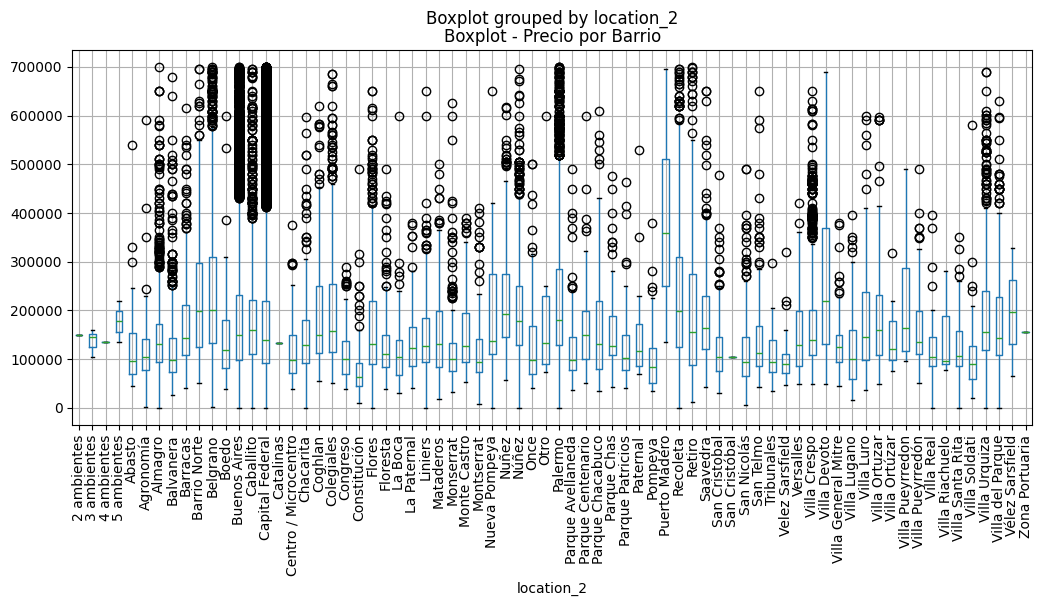

In [18]:
fig, ax1 = plt.subplots(figsize=(12, 5))

df_ent.boxplot(by="location_2", column="price", ax=ax1)
ax1.set_title("Boxplot - Precio por Barrio")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


plt.show()

Se observa en el campo barrio (location_2): 2 ambientes, 3 ambientes, 4 ambientes, 5 ambientes
Se observa outliers en location_2: Palermo, Capital Federal, Buenos Aires, Villa Crespo y Villa Urquiza principalmente.


## 2.4. Imputación de valores perdidos

Me voy a enfocar en las siguientes variables:
1. description       106184 non-null  object
2.   address           105719 non-null  object
3.   lat               44691 non-null   float64
4.   lon               44692 non-null   float64
5.   publication_date  44692 non-null   object
6.   publisher_id      75848 non-null   float64
7.   features
8. source            104804 non-null  object  

In [19]:
# Address NA se imputa con "sin info"
df_ent["address"].fillna("sin info", inplace=True)

# Description NA se imputa con "sin info"
df_ent["description"].fillna("sin info", inplace=True)

# La moda de primera mano no sirve, porque el dato es basura (photo)
# Me quedo con el segundo valor de la moda "23 nov 2022"
df_ent.loc[df_ent['publication_date'] == "photo", "publication_date"] = "23 nov 2022"
# Ahora reemplazo los NA con la moda
public_dat_moda = df_ent['publication_date'].mode()[0]
df_ent['publication_date'].fillna(public_dat_moda, inplace=True)


# Imputo PUBLISHER por la moda
publi_id_moda = df_ent["publisher_id"].mode()[0]
df_ent["publisher_id"].fillna(publi_id_moda, inplace=True)
# casteo a entero
df_ent["publisher_id"] = df_ent["publisher_id"].astype(int)


# Imputo FEATURES con "sin info"
df_ent["features"].fillna("sin info", inplace=True)


# imputo LOCATION 3 y 4 con "sin info"
df_ent["location_3"].fillna("sin info", inplace=True)
df_ent["location_4"].fillna("sin info", inplace=True)


# imputo SOURCE con "sin info"
df_ent["source"].fillna("sin info", inplace=True)

/tmp/ipykernel_4347/3368416880.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ent["address"].fillna("sin info", inplace=True)
/tmp/ipykernel_4347/3368416880.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

NOTA: Esto lo tengo que ejecutar dos veces seguidas, para que tome la conversión a número.

In [22]:
# imputo cantidad de DORMITORIOS con la moda
df_ent["c_dormitorios"] = df_ent["c_dormitorios"].astype(int, errors="ignore") # convierto a numerico
cant_dormitorio_moda = int(df_ent["c_dormitorios"].mode()[0]) # calculo la moda
df_ent["c_dormitorios"].fillna(cant_dormitorio_moda, inplace=True)


# Imputo cantidad BAÑOS con la moda
df_ent["c_baños"] =  df_ent["c_baños"].astype(int, errors="ignore")  # convierto a numerico
banio_moda = int(df_ent["c_baños"].mode()[0])       # calculo la moda
df_ent["c_baños"].fillna(banio_moda, inplace=True)

# # imputo SUPERFICIE con el promedio
df_ent['superficie'] = df_ent['superficie'].astype(float)                 # convierto a numerico
superficie_promedio = df_ent['superficie'].astype(float).mean().round(2)  # promedio
df_ent['superficie'].fillna(superficie_promedio, inplace=True)


print(df_ent.isna().sum())

description             0
address                 0
lat                 61495
lon                 61494
publication_date        0
publisher_id            0
features                0
location_0              0
location_1              0
location_2              4
location_3              0
location_4              0
operation_type          0
property_type           0
source                  0
price                   0
currency_type           0
c_dormitorios           0
c_baños                 0
garage                  0
superficie              0
dtype: int64


/tmp/ipykernel_4347/399744372.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ent["c_dormitorios"].fillna(cant_dormitorio_moda, inplace=True)
/tmp/ipykernel_4347/399744372.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [23]:
df_ent.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106186 entries, 3659 to 1270469
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   description       106186 non-null  object 
 1   address           106186 non-null  object 
 2   lat               44691 non-null   float64
 3   lon               44692 non-null   float64
 4   publication_date  106186 non-null  object 
 5   publisher_id      106186 non-null  int64  
 6   features          106186 non-null  object 
 7   location_0        106186 non-null  object 
 8   location_1        106186 non-null  object 
 9   location_2        106182 non-null  object 
 10  location_3        106186 non-null  object 
 11  location_4        106186 non-null  object 
 12  operation_type    106186 non-null  object 
 13  property_type     106186 non-null  object 
 14  source            106186 non-null  object 
 15  price             106186 non-null  float64
 16  currency_type     106

## Antes de entrenar, hacer backup

In [24]:
# Ante de entrenar, hacer backup
df_ent_bkp = df_ent.copy()
# df_ent = df_ent_bkp.copy()

## 3. Entrenamiento del modelos (AA)- ⛔⛔⛔ NO TOCAR NADA DE ESTA SECCIÓN ⛔⛔⛔

In [25]:
# La creación de modelos requiere que todo el dataframe sea numérico
# Me quedo con las columnas numéricas solamente
df_ent = df_ent.select_dtypes('number')

X = df_ent[df_ent.columns.drop('price')]
y = df_ent['price']

In [26]:
X.columns

Index(['lat', 'lon', 'publisher_id', 'c_dormitorios', 'c_baños', 'superficie'], dtype='object')

In [27]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

# Definimos el valor de los hiperparámetros a usar por el modelo
n_estimators = 500
max_depth = 50

# Creamos el modelo a entrenar
reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)

# Entrenamos el modelo
_ = reg.fit(X_train, y_train)

# Cálculo del error en entrenamiento (train)
y_pred = reg.predict(X_train)
score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)

# Cálculo del error en prueba (test)
y_pred = reg.predict(X_test)
score_test  = sk.metrics.root_mean_squared_error(y_test,  y_pred)

print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f}")

n_estimators=500 -- max_depth=50 --> score_train=33691.36 - score_test=70894.74


## 3.1. (Opcional) Validación Cruzada para mejorar el modelo a partir de los datos

Esta técnica permite mejorar el modelo adaptando los hiperparámetros a los datos seleccionados

**NOTA**: Esta técnica puede tardar mucho, se recomienda ir probando pocos valores en paralelo al resto de los analisis.

In [ ]:
# definimos el valor de los hiperparámetros
n_estimators = 500
max_depth = 50

# Creamos el modelo
# No cambiar RandomForestRegressor
reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)

scores_train = []
scores_test = []

# Validación cruzada, 10 folds, shuffle antes, semilla aleatoria
kf = sk.model_selection.KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Partimos el fold en entrenamiento y prueba...
    X_train, X_test, y_train, y_test = X.iloc[train_index], X.iloc[test_index], y.iloc[train_index], y.iloc[test_index]

    # Entrenamos el modelo en entramiento
    reg.fit(X_train, y_train)

    # Predecimos en train
    y_pred = reg.predict(X_train)

    # Medimos la performance de la predicción en entramiento
    score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)

    # Predecimos en test
    y_pred = reg.predict(X_test)

    # Medimos la performance de la predicción en prueba
    score_test = sk.metrics.root_mean_squared_error(y_test, y_pred)

    print("\t", f"{fold=}, {score_train=} {score_test=}")


## 3.2. Análisis de la importancia de variables en el modelo (opcional)

Una manera visual de entender a que variable el modelo le está prestando mayor atención.

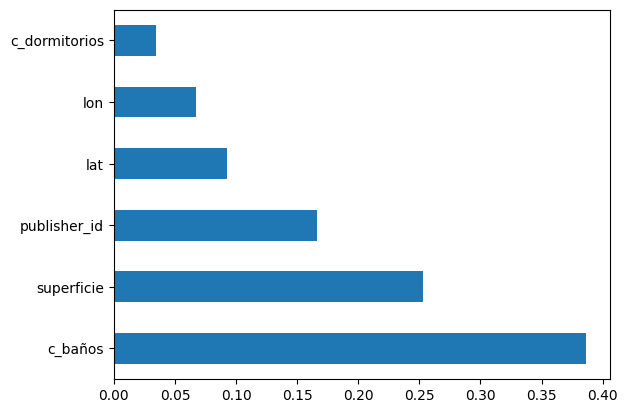

In [28]:
feat_importances = pd.Series(reg.feature_importances_, index=X.columns)

# gráfico de barras horizontales
feat_importances.nlargest(10).plot(kind='barh');

In [ ]:
X.columns

Index(['lat', 'lon', 'publisher_id', 'c_dormitorios', 'c_baños', 'superficie'], dtype='object')

## 4. Solución para subir Kaggle

In [29]:
df_ap = pd.read_csv(f"{DIR}/a_predecir.csv", index_col="id")
# df_ap.head(2)

In [ ]:
df_ap.shape

In [30]:
X = df_ent[df_ent.columns.drop('price')]
y = df_ent['price']

# # Si se hizo la validación cruzada usa el mejor valor encontrado, sino, ponemos valores por defecto
# best_n_estimators = mejor_combinacion["n_estimators"] if mejor_combinacion["n_estimators"] is not None else 50
# best_max_depth = mejor_combinacion["max_depth"] if mejor_combinacion["max_depth"] is not None else 5
# reg = sk.ensemble.RandomForestRegressor(n_estimators=best_n_estimators, max_depth=best_max_depth, n_jobs=-1, random_state=42)

# Definimos el valor de los hiperparámetros a usar por el modelo
n_estimators = 500
max_depth = 50
# Creamos el modelo a entrenar
reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)


# Entrenamos el modelo con todos los datos de entrenamiento.csv
reg.fit(X, y)

RandomForestRegressor(max_depth=50, n_estimators=500, n_jobs=-1,
                      random_state=42)

## 4.2. Generación del archivo para Kaggle

Hacer en df_ap el mismo proceso que se realizó para los datos de entrenamiento

**Creación de nuevos atributos**

In [31]:
# dormitorios
dormitorios = df_ap.loc[:,"features"].str.extract(r"(\d+) dormitorios;|dormitorio: (\d+);|dormitorios:(\d+);")
df_ap["c_dormitorios"] = dormitorios[0].fillna(dormitorios[1]).fillna(dormitorios[2])

#
# baños
banios = df_ap.loc[:,"features"].str.extract(r"(\d+) baños;|bano: (\d+);|baños:(\d+);")
df_ap["c_baños"] = banios[0].fillna(banios[1]).fillna(banios[2])

# # el garage solo anotaremos tiene SI o NO
garage = df_ap.loc[:,"features"].str.extract(r'(garage);|(cochera):|(cocheras):\d+')
df_ap["garage"]  = garage[0].fillna(garage[1]).fillna(garage[2])
df_ap.loc[df_ap["garage"].isin(["garage","cochera","cocheras"]) , "garage"] = True
df_ap["garage"].fillna(False, inplace=True)

# Superficie
superficie = df_ap.loc[:,"features"].str.extract(r";(\d+)\s*m²|scubierta: (\d+);| superficie total:(\d+)m.{1};|sup.\scubierta:(\d+)\s*m²| tcubierta:\s(\d*,\d*)\sm²| superficie\stotal:\s(\d+)")
df_ap["superficie"] = superficie[0].fillna(superficie[1]).fillna(superficie[2]).fillna(superficie[3]).fillna(superficie[4]).fillna(superficie[5])


/tmp/ipykernel_4347/4081900381.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ap["garage"].fillna(False, inplace=True)
/tmp/ipykernel_4347/4081900381.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ap["garage"].fillna(False, inplace=True)


In [ ]:
df_ap["garage"].isna().sum()

np.int64(0)

**Imputación de valores perdidos**

In [32]:
# Address NA se imputa con "sin info"
df_ap["address"].fillna("sin info", inplace=True)

# Description NA se imputa con "sin info"
df_ap["description"].fillna("sin info", inplace=True)

# Fecha de publicacion == NA se imputa con la moda
df_ap["description"].fillna("sin info", inplace=True)


# La moda de primera mano no sirve, porque el dato es basura (photo)
# Me quedo con el segundo valor de la moda "23 nov 2022"
df_ap.loc[df_ap['publication_date'] == "photo", "publication_date"] = "23 nov 2022"
# Ahora reemplazo los NA con la moda
public_dat_moda = df_ap['publication_date'].mode()[0]
df_ap['publication_date'].fillna(public_dat_moda, inplace=True)


# Imputo PUBLISHER por la moda
publi_id_moda = df_ap["publisher_id"].mode()[0]
df_ap["publisher_id"].fillna(publi_id_moda, inplace=True)
# casteo a entero
df_ap["publisher_id"] = df_ap["publisher_id"].astype(int)


# Imputo FEATURES con "sin info"
df_ap["features"].fillna("sin info", inplace=True)


# imputo LOCATION 3 y 4 con "sin info"
df_ap["location_3"].fillna("sin info", inplace=True)
df_ap["location_4"].fillna("sin info", inplace=True)


# imputo SOURCE con "sin info"
df_ap["source"].fillna("sin info", inplace=True)

/tmp/ipykernel_4347/3199045660.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ap["address"].fillna("sin info", inplace=True)
/tmp/ipykernel_4347/3199045660.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

correr dos veces

In [35]:
# imputo cantidad de DORMITORIOS con la moda
df_ap["c_dormitorios"] = df_ap["c_dormitorios"].astype(int, errors="ignore") # convierto a numerico
cant_dormitorio_moda = int(df_ap["c_dormitorios"].mode()[0]) # calculo la moda
df_ap["c_dormitorios"].fillna(cant_dormitorio_moda, inplace=True)


# Imputo cantidad BAÑOS con la moda
df_ap["c_baños"] =  df_ap["c_baños"].astype(int, errors="ignore")  # convierto a numerico
banio_moda = int(df_ap["c_baños"].mode()[0])       # calculo la moda
df_ap["c_baños"].fillna(banio_moda, inplace=True)

# # imputo SUPERFICIE con el promedio
df_ap['superficie'] = df_ap['superficie'].astype(float)                 # convierto a numerico
superficie_promedio = df_ap['superficie'].astype(float).mean().round(2)  # promedio
df_ap['superficie'].fillna(superficie_promedio, inplace=True)


print(df_ap.isna().sum())

description             0
address                 0
lat                  9947
lon                  9947
publication_date        0
publisher_id            0
features                0
location_0              0
location_1              0
location_2              0
location_3              0
location_4              0
operation_type          0
property_type           0
source                  0
price               13471
currency_type           0
c_dormitorios           0
c_baños                 0
garage                  0
superficie              0
dtype: int64


/tmp/ipykernel_4347/2477299201.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ap["c_dormitorios"].fillna(cant_dormitorio_moda, inplace=True)
/tmp/ipykernel_4347/2477299201.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [36]:
df_ap.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13471 entries, 264893 to 696882
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   description       13471 non-null  object 
 1   address           13471 non-null  object 
 2   lat               3524 non-null   float64
 3   lon               3524 non-null   float64
 4   publication_date  13471 non-null  object 
 5   publisher_id      13471 non-null  int64  
 6   features          13471 non-null  object 
 7   location_0        13471 non-null  object 
 8   location_1        13471 non-null  object 
 9   location_2        13471 non-null  object 
 10  location_3        13471 non-null  object 
 11  location_4        13471 non-null  object 
 12  operation_type    13471 non-null  object 
 13  property_type     13471 non-null  object 
 14  source            13471 non-null  object 
 15  price             0 non-null      float64
 16  currency_type     13471 non-null  objec

In [37]:
# # TODO: Hacer en df_ap la misma limpieza que en df_ent
# df_ap = df_ap.fillna(0)

df_ap = df_ap.select_dtypes('number')

X_ap = df_ap[X.columns]

# Predecimos los precios del dataset a predecir
y_pred_ap = reg.predict(X_ap)
y_pred_ap

array([496450.812     , 178926.93      , 260468.        , ...,
        47113.88413333,  41941.70804329,  36360.40809524])

In [38]:
df_ap.select_dtypes('number')


,lat,lon,publisher_id,price,c_dormitorios,c_baños,superficie
id,,,,,,,
264893,-34.601357,-58.378109,101951,NaN,4,4,308.0
264899,-34.614742,-58.390285,101951,NaN,3,3,91.0
264910,-34.608849,-58.378567,101951,NaN,3,2,186.0
264915,-34.601772,-58.386559,101951,NaN,3,1,79.0
264919,-34.606712,-58.392914,101951,NaN,2,1,34.0
...,...,...,...,...,...,...,...
72571,-34.585030,-58.412045,101951,NaN,2,1,21.0
72713,-34.620113,-58.430485,101951,NaN,2,1,20.0
696861,-34.608000,-58.430000,7366,NaN,2,1,19.0


In [ ]:
DIR_out = "/content/drive/MyDrive" + "/UBA/Especializacion/DM/Segunda-entrega/"

# Lleno el precio de df_ap con las predicciones
df_ap["price"] = y_pred_ap

# Grabo el df_ap en un archivo csv para subir a Kaggle
nombre = "e2v1-2"
df_ap["price"].to_csv(f"{DIR_out}/solucion-{nombre}.csv")